# Importation des librairies

In [95]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential, load_model,Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

import sys
import platform
import warnings
warnings.filterwarnings(action='ignore')

import cv2
import shutil

## Graines

In [96]:
# Seed for reproducibility
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

## Chargement des données

In [97]:
# Nombre de classes en sortie : Pierre, Feuille, Ciseaux
num_classes = 3

In [98]:
X_train, y_train = tfds.as_numpy(tfds.load(
    'rock_paper_scissors',
    split='train',
    batch_size=-1,
    as_supervised=True,
))

In [99]:
X_test, y_test = tfds.as_numpy(tfds.load(
    'rock_paper_scissors',
    split='test',
    batch_size=-1,
    as_supervised=True,
))

In [100]:
# Compte le nombre d'exemples par classe dans l'ensemble d'entraînement
unique_train_classes, counts_train = np.unique(y_train, return_counts=True)

# Compte le nombre d'exemples par classe dans l'ensemble de test
unique_test_classes, counts_test = np.unique(y_test, return_counts=True)

# Affiche les résultats
print("Nombre d'exemples par classe dans l'ensemble d'entraînement :")
for i, cls in enumerate(unique_train_classes):
    print(f"Classe {cls}: {counts_train[i]} exemples")

print("\nNombre d'exemples par classe dans l'ensemble de test :")
for i, cls in enumerate(unique_test_classes):
    print(f"Classe {cls}: {counts_test[i]} exemples")

Nombre d'exemples par classe dans l'ensemble d'entraînement :
Classe 0: 840 exemples
Classe 1: 840 exemples
Classe 2: 840 exemples

Nombre d'exemples par classe dans l'ensemble de test :
Classe 0: 124 exemples
Classe 1: 124 exemples
Classe 2: 124 exemples


In [101]:
# On ajoute le sous-ensemble de validation (20% du train)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
    stratify=y_train
)

# Pré-traitement des données

In [102]:
#X_train = tf.image.resize(X_train, (224, 224))
#X_test = tf.image.resize(X_test, (224, 224))
#X_validation = tf.image.resize(X_validation, (224, 224))

# Le modèle pré-entraîné Mobilenet comme vgg16 s'attends à des images d'entrée au format 244,244,3 alors que nos images font 300,300,3, il faut donc les redimensionner au format attendu par le modèle 
def preprocess_images(images):
    images = tf.image.resize(images, (224, 224))
    images = images / 255.0
    return images

X_train = preprocess_images(X_train)
X_validation  = preprocess_images(X_validation)
X_test = preprocess_images(X_test)


print("Tensor shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_validation.shape, y_validation.shape)

Tensor shapes: (2016, 224, 224, 3) (2016,) (372, 224, 224, 3) (372,) (504, 224, 224, 3) (504,)


# Création du modèle

In [103]:
# Load the MobileNetV2 model
mobilenet_model = MobileNetV2(
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the layers of the pre-trained model
for layer in mobilenet_model.layers:
    layer.trainable = False

# Create your custom model
model = Sequential()
model.add(mobilenet_model)
model.add(GlobalAveragePooling2D())  # Add Global Average Pooling layer
model.add(Dense(128, activation='relu'))

model.add(Dense(num_classes, activation='softmax'))

# Vous pouvez choisir de décongeler toutes les couches ou seulement certaines d'entre elles
#for layer in mobilenet_model.layers[:-20]:  # Dégeler toutes les couches sauf les 20 dernières
    #layer.trainable = True

In [104]:
'''Compilez le modèle en spécifiant l'optimiseur et la fonction de perte
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Créez un callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Métrique à surveiller (perte sur les données de validation)
    patience=5,           # Nombre d'époques sans amélioration avant l'arrêt
    verbose=1,            # Afficher des messages pendant l'entraînement
    restore_best_weights=True  # Restaurer les meilleurs poids du modèle
)

#data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,       # Rotation aléatoire de l'image de -20 à +20 degrés
    width_shift_range=0.2,  # Déplacement horizontal aléatoire
    height_shift_range=0.2, # Déplacement vertical aléatoire
    shear_range=0.2,        # Inclinaison aléatoire
    zoom_range=0.2,         # Zoom aléatoire
    horizontal_flip=True,   # Retournement horizontal aléatoire
    fill_mode='nearest'     # Mode de remplissage pour les nouvelles pixels générées
)
# Appliquer la data augmentation aux images d'entraînement
augmented_images = datagen.flow(X_train, y_train, batch_size=32, shuffle=True)

# Utiliser augmented_images comme générateur d'entraînement
history=model.fit(augmented_images, epochs=50, validation_data=(X_validation, y_validation),callbacks=[early_stopping])'''


"Compilez le modèle en spécifiant l'optimiseur et la fonction de perte\nmodel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])\n\n# Créez un callback EarlyStopping\nearly_stopping = EarlyStopping(\n    monitor='val_loss',  # Métrique à surveiller (perte sur les données de validation)\n    patience=5,           # Nombre d'époques sans amélioration avant l'arrêt\n    verbose=1,            # Afficher des messages pendant l'entraînement\n    restore_best_weights=True  # Restaurer les meilleurs poids du modèle\n)\n\n#data augmentation\ndatagen = ImageDataGenerator(\n    rotation_range=20,       # Rotation aléatoire de l'image de -20 à +20 degrés\n    width_shift_range=0.2,  # Déplacement horizontal aléatoire\n    height_shift_range=0.2, # Déplacement vertical aléatoire\n    shear_range=0.2,        # Inclinaison aléatoire\n    zoom_range=0.2,         # Zoom aléatoire\n    horizontal_flip=True,   # Retournement horizontal aléatoire\n    fill_mode='neares

# Compilation du modèle

In [105]:
# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_5  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 128)               163968    
                                                                 
 dense_11 (Dense)            (None, 3)                 387       
                                                                 
Total params: 2422339 (9.24 MB)
Trainable params: 164355 (642.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [106]:
datagen = ImageDataGenerator(
    rotation_range=40,  # Rotation aléatoire dans la plage de -40 à 40 degrés
    width_shift_range=0.2,  # Déplacement horizontal aléatoire de 20% de la largeur de l'image
    height_shift_range=0.2,  # Déplacement vertical aléatoire de 20% de la hauteur de l'image
    shear_range=0.2,        # Inclinaison aléatoire
    zoom_range=0.2,  # Zoom aléatoire de 20%
    horizontal_flip=True,  # Retournement horizontal aléatoire
    fill_mode='nearest'  # Mode de remplissage pour les pixels nouvellement créés
)

In [107]:
# Appliquer la data augmentation à l'ensemble d'entraînement
augmented_train_data = datagen.flow(X_train, y_train, batch_size=32)

# Appliquer la data augmentation à l'ensemble de validation (si nécessaire)
#augmented_validation_data = datagen.flow(X_validation, y_validation, batch_size=32)

# Entrainement du modèle

In [108]:
# Define early stopping and model checkpoint callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)
checkpoint = ModelCheckpoint('MobilnetV2-shifumi.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

In [109]:
#from keras.models import load_model

# Chargement du modèle depuis un fichier .h5
#modele = load_model("MobilnetV2-shifumi.h5")

In [110]:
# Entraînement du modèle
history = model.fit(
    #x=X_train,
    #y=y_train,
    x=augmented_train_data,
    epochs=50,
    batch_size=32,
    validation_data=(X_validation, y_validation),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
63/63 [==============================] - ETA: 0s - loss: 0.2248 - accuracy: 0.9112
Epoch 1: val_accuracy improved from -inf to 0.99405, saving model to MobilnetV2-shufumi.h5
63/63 [==============================] - 31s 457ms/step - loss: 0.2248 - accuracy: 0.9112 - val_loss: 0.0350 - val_accuracy: 0.9940
Epoch 2/50
63/63 [==============================] - ETA: 0s - loss: 0.0406 - accuracy: 0.9881
Epoch 2: val_accuracy improved from 0.99405 to 0.99802, saving model to MobilnetV2-shufumi.h5
63/63 [==============================] - 28s 443ms/step - loss: 0.0406 - accuracy: 0.9881 - val_loss: 0.0110 - val_accuracy: 0.9980
Epoch 3/50
63/63 [==============================] - ETA: 0s - loss: 0.0284 - accuracy: 0.9926
Epoch 3: val_accuracy improved from 0.99802 to 1.00000, saving model to MobilnetV2-shufumi.h5
63/63 [==============================] - 28s 443ms/step - loss: 0.0284 - accuracy: 0.9926 - val_loss: 0.0085 - val_accuracy: 1.0000
Epoch 4/50
63/63 [=========================

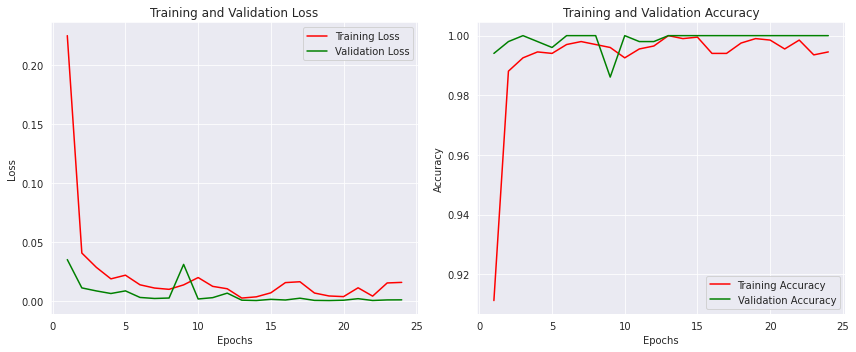

In [111]:
def plot_learning_curves(history):
    # Extraire les données d'apprentissage
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    # Créer une liste d'époques
    epochs = range(1, len(loss) + 1)

    # Tracer les courbes de perte
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'g', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Tracer les courbes d'exactitude
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, 'r', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'g', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Utilisez cette fonction pour tracer les courbes d'apprentissage
plot_learning_curves(history)

# Performances du modèle sur le jeu d'apprentissage

### Taux de classification

In [112]:
model.evaluate(X_train, y_train)

63/63 [==============================] - 15s 231ms/step - loss: 2.2622e-04 - accuracy: 1.0000


[0.00022622235701419413, 1.0]

### Matrice de confusion

In [113]:
y_predict_train = np.argmax(model.predict(X_train), axis=-1)

63/63 [==============================] - 15s 229ms/step


In [114]:
cm = confusion_matrix(y_train, y_predict_train, normalize='true')

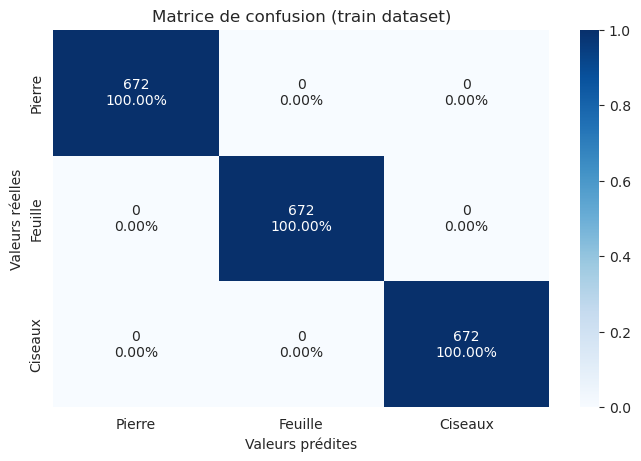

In [115]:
counts = ["{0:0.0f}\n".format(value) for value in confusion_matrix(y_train, y_predict_train, normalize=None).flatten()]
percentages = ["{0:.2%}".format(value) for value in confusion_matrix(y_train, y_predict_train, normalize='true').flatten()]

box_labels = [f"{v1}{v2}" for v1, v2 in zip(counts, percentages)]
box_labels = np.asarray(box_labels).reshape(cm.shape[0],cm.shape[1])

plt.figure(figsize=(8,5), dpi=100)

plt.title("Matrice de confusion (train dataset)")

sns.heatmap(cm,
            vmin=0.0,
            vmax=1.0,
            cmap='Blues',
            annot=box_labels,
            fmt='',
            xticklabels=["Pierre", "Feuille", "Ciseaux"],
            yticklabels=["Pierre", "Feuille", "Ciseaux"])

plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")

plt.show()

# Performances du modèle sur le jeu de validation

### Taux de classification

In [116]:
model.evaluate(X_validation, y_validation)

16/16 [==============================] - 4s 227ms/step - loss: 3.1633e-04 - accuracy: 1.0000


[0.00031632656464353204, 1.0]

### Matrice de confusion

In [117]:
y_predict_validation = np.argmax(model.predict(X_validation), axis=-1)

16/16 [==============================] - 4s 225ms/step


In [118]:
cm = confusion_matrix(y_validation, y_predict_validation, normalize='true')

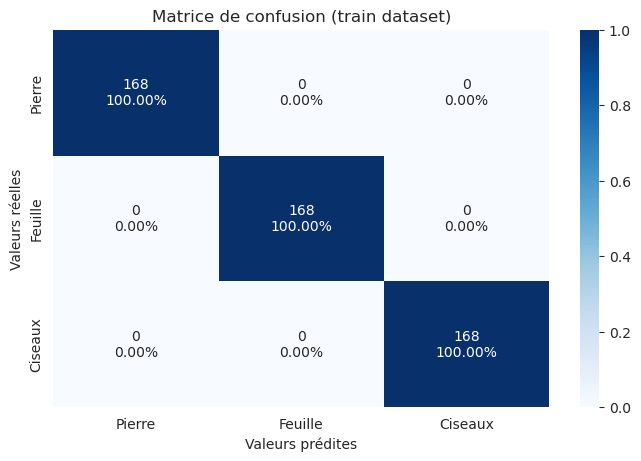

In [119]:
counts = ["{0:0.0f}\n".format(value) for value in confusion_matrix(y_validation, y_predict_validation, normalize=None).flatten()]
percentages = ["{0:.2%}".format(value) for value in confusion_matrix(y_validation, y_predict_validation, normalize='true').flatten()]

box_labels = [f"{v1}{v2}" for v1, v2 in zip(counts, percentages)]
box_labels = np.asarray(box_labels).reshape(cm.shape[0],cm.shape[1])

plt.figure(figsize=(8,5), dpi=100)

plt.title("Matrice de confusion (train dataset)")

sns.heatmap(cm,
            vmin=0.0,
            vmax=1.0,
            cmap='Blues',
            annot=box_labels,
            fmt='',
            xticklabels=["Pierre", "Feuille", "Ciseaux"],
            yticklabels=["Pierre", "Feuille", "Ciseaux"])

plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")

plt.show()

# Performances du modèle sur le jeu de test


## Taux de classification



In [120]:
model.evaluate(X_test, y_test)

12/12 [==============================] - 3s 220ms/step - loss: 0.2426 - accuracy: 0.9489


[0.2425878643989563, 0.948924720287323]

## Matrice de confusion

In [121]:
y_predict_test = np.argmax(model.predict(X_test), axis=-1)

12/12 [==============================] - 3s 217ms/step


In [122]:
cm = confusion_matrix(y_test, y_predict_test, normalize='true')

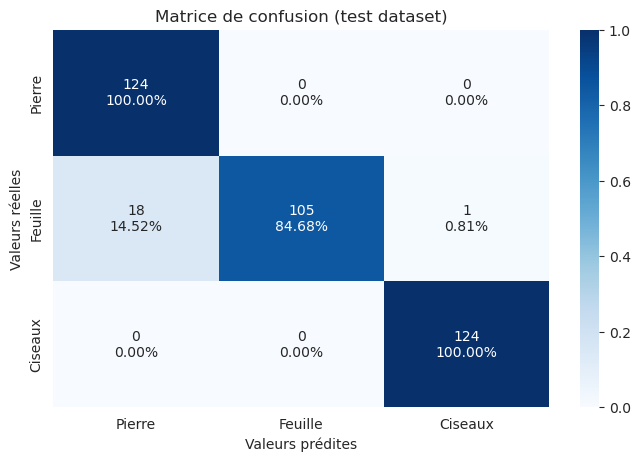

In [123]:
counts = ["{0:0.0f}\n".format(value) for value in confusion_matrix(y_test, y_predict_test, normalize=None).flatten()]
percentages = ["{0:.2%}".format(value) for value in confusion_matrix(y_test, y_predict_test, normalize='true').flatten()]

box_labels = [f"{v1}{v2}" for v1, v2 in zip(counts, percentages)]
box_labels = np.asarray(box_labels).reshape(cm.shape[0],cm.shape[1])

plt.figure(figsize=(8,5), dpi=100)

plt.title("Matrice de confusion (test dataset)")

sns.heatmap(cm,
            vmin=0.0,
            vmax=1.0,
            cmap='Blues',
            annot=box_labels,
            fmt='',
            xticklabels=["Pierre", "Feuille", "Ciseaux"],
            yticklabels=["Pierre", "Feuille", "Ciseaux"])

plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")

plt.show()

In [124]:
from sklearn.metrics import classification_report
# Display classification report
class_names = ["Pierre", "Feuille", "Ciseaux"]
print("Classification Report:")
print(classification_report(y_test, y_predict_test, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

      Pierre       0.87      1.00      0.93       124
     Feuille       1.00      0.85      0.92       124
     Ciseaux       0.99      1.00      1.00       124

    accuracy                           0.95       372
   macro avg       0.96      0.95      0.95       372
weighted avg       0.96      0.95      0.95       372



In [125]:
#model.save('Mobilnet-transferlearning-shufumi.h5')

# Test de prédiction

1/1 [==============================] - 0s 31ms/step


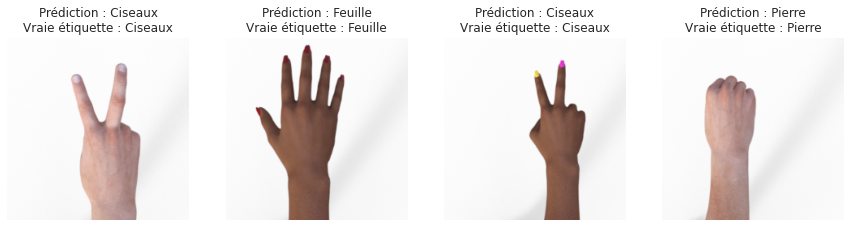

1/1 [==============================] - 0s 29ms/step


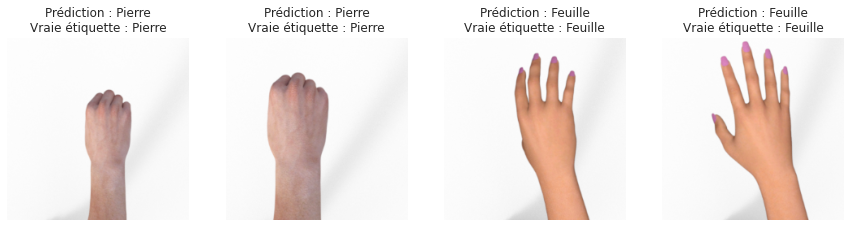

In [126]:
# Charger le modèle pré-entraîné
model = tf.keras.models.load_model('MobilnetV2-shifumi.h5')

# Charger le jeu de données Rock-Paper-Scissors
data_test = tfds.load('rock_paper_scissors', split='test', batch_size=-1, as_supervised=True)
X_test, y_test = tfds.as_numpy(data_test)

# Redimensionner les images
X_test = tf.image.resize(X_test, (224, 224))

# Prétraitement des images (normalisation)
X_test = X_test / 255.0

# Effectuer des prédictions sur un échantillon d'images
num_samples = len(X_test)
num_images_per_row = 4  # Nombre d'images par ligne
num_rows_to_display = 2  # Nombre de rangées à afficher

for row in range(num_rows_to_display):
    start_idx = row * num_images_per_row
    end_idx = min(start_idx + num_images_per_row, num_samples)
    sample_images = X_test[start_idx:end_idx]
    sample_labels = y_test[start_idx:end_idx]

    plt.figure(figsize=(15, 4))  # Ajustez la taille de la figure
    for i in range(end_idx - start_idx):
        image = sample_images[i:i+1]  # Sélectionner une seule image
        prediction = model.predict(image)
        predicted_class = tf.argmax(prediction, axis=1)[0].numpy()

        # Traduire la classe prédite en une étiquette (Roche, Papier ou Ciseaux)
        labels = ['Pierre', 'Feuille', 'Ciseaux']
        predicted_label = labels[predicted_class]

        # Obtenir l'étiquette réelle (vraie étiquette) de l'échantillon
        true_class = sample_labels[i]
        true_label = labels[true_class]

        # Afficher l'image, l'étiquette prédite et la vraie étiquette
        plt.subplot(1, num_images_per_row, i + 1)
        plt.imshow(image[0])
        plt.title(f'Prédiction : {predicted_label}\nVraie étiquette : {true_label}')
        plt.axis('off')
    plt.show()